In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5
G_lo = 20.0

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [9]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [10]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [11]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(zbin_array)-1))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))
cmaps = [cmap_red, cmap_blue]

In [12]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)
blue = plt.get_cmap('Blues')((0.333+0.999)/2)
red = plt.get_cmap('Reds')((0.333+0.999)/2)
colors = [red, blue]
G_array = [G_lo, G_hi]

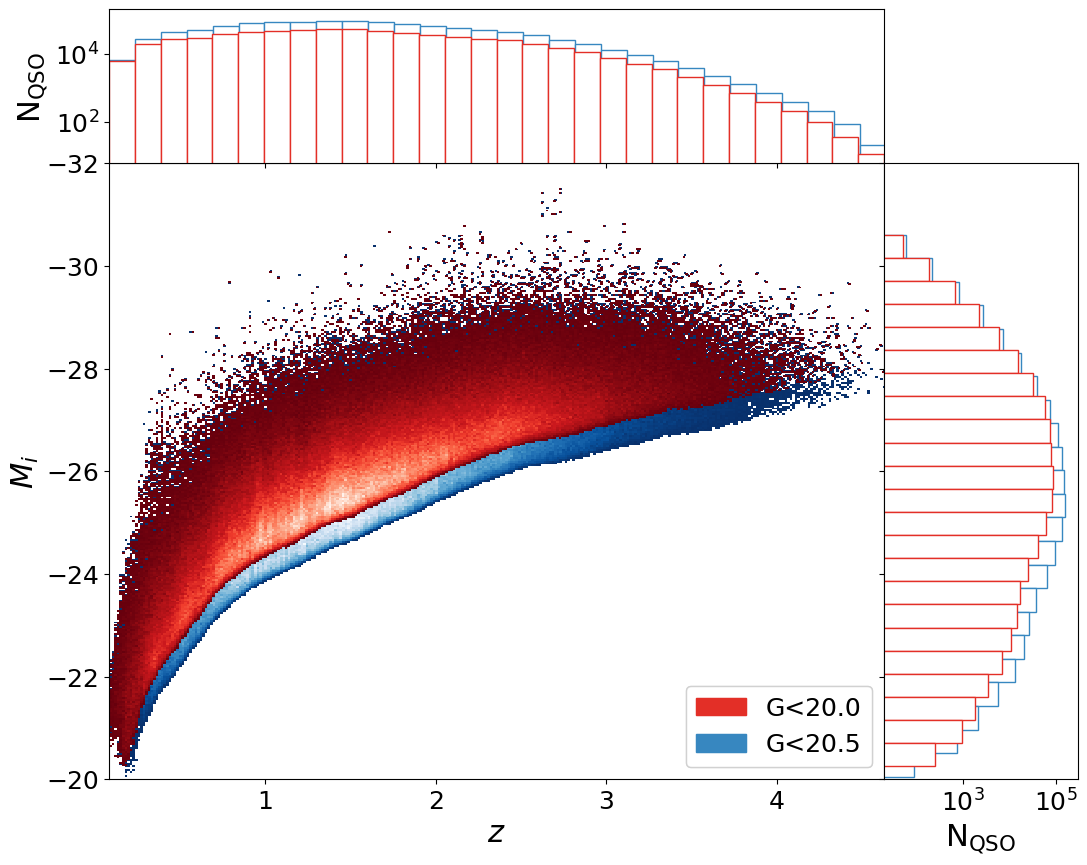

In [13]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = ax1.legend(handles=patch, loc = 'lower right')
ax1.add_artist(first_legend)

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in four z bins
## $\xi(s)$

In [14]:
# Create the bins array
rmin = 0.1
rmax = 180.0
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

_G20.0_zmin0.0zmax1.0


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin1.0zmax2.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin2.0zmax3.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin3.0zmax4.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


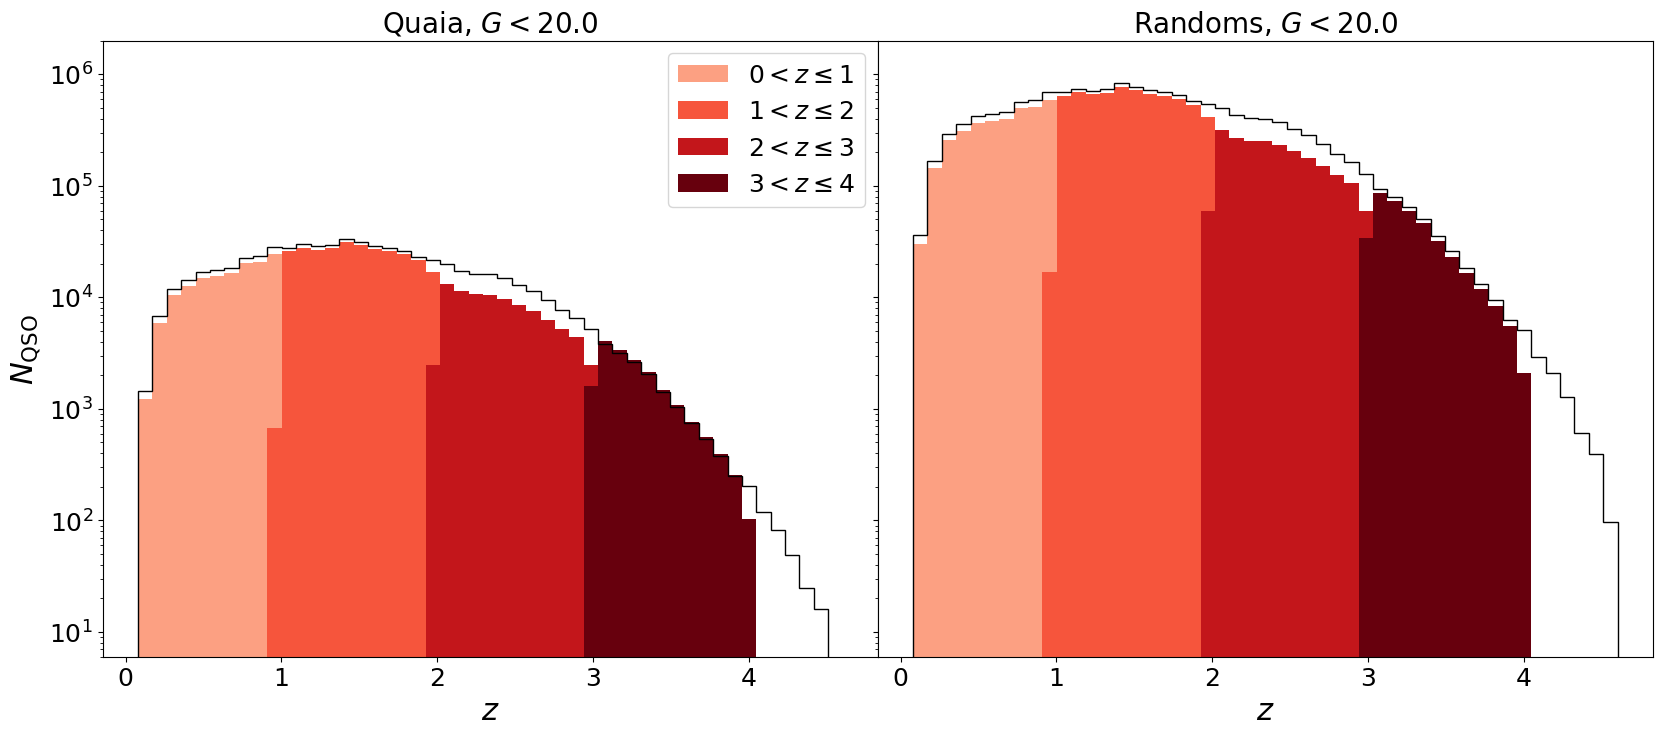

_G20.5_zmin0.0zmax1.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin1.0zmax2.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin2.0zmax3.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin3.0zmax4.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


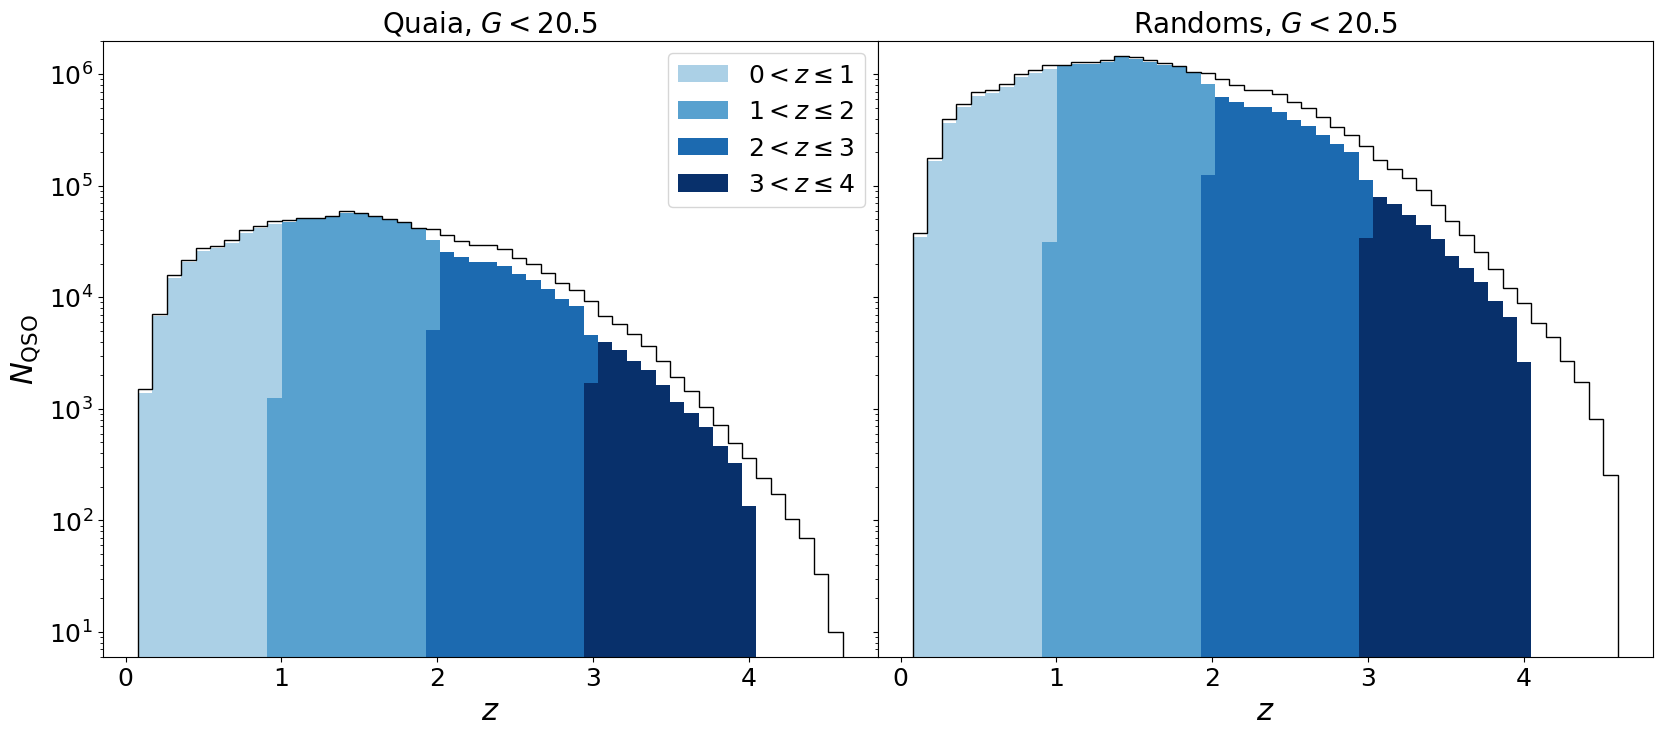

In [15]:
# plot data
bins = np.linspace(0.08, 4.6)
cf = {20.0: [], 20.5: []}
for G, cmap in zip(G_array, cmaps):

    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    fn_datahi = '../data/quaia_G{}.fits'.format(G)
    tab_datahi = Table.read(fn_datahi)
    pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
    mask_datahi = selfunc_hi[pixel_indices_datahi]>=0.5

    # plot!
    fig = plt.figure(figsize = (20, 8))
    gs = gridspec.GridSpec(1, 2, wspace = 0)

    ax1 = fig.add_subplot(gs[0])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

    # plot randoms  
    ax2 = fig.add_subplot(gs[1])

    # for comparison purposes
    fn_randhi = '../data/randoms/random_G{}_25x.fits'.format(G)
    tab_randhi = Table.read(fn_randhi)
    pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5
    N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
             color = 'black')

    for zbin in zbin_array[:-1]:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G, int(zbin),True, 'z', bins = zbin_array, 
                                                                                           tab_gcat_type = 'data', method = 'minmax', fac_rand = 25)
        ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 bins = bins, color = cmap[int(zbin)])
        ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
                 bins = bins, color = cmap[int(zbin)])
        
        cf[G].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))

    ax1.set_xlabel('$z$')
    ax1.set_ylabel('$N_\mathrm{QSO}$')
    ax1.set_yscale('log')
    ax1.set_ylim(6,2e6)
    ax1.set_title('Quaia, $G<{}$'.format(G))
    ax1.legend()

    ax2.set_xlabel('$z$')
    ax2.set_yscale('log')
    ax2.set_ylim(6,2e6)
    ax2.set_title('Randoms, $G<{}$'.format(G))
    ax2.set_yticklabels([])
    plt.show()

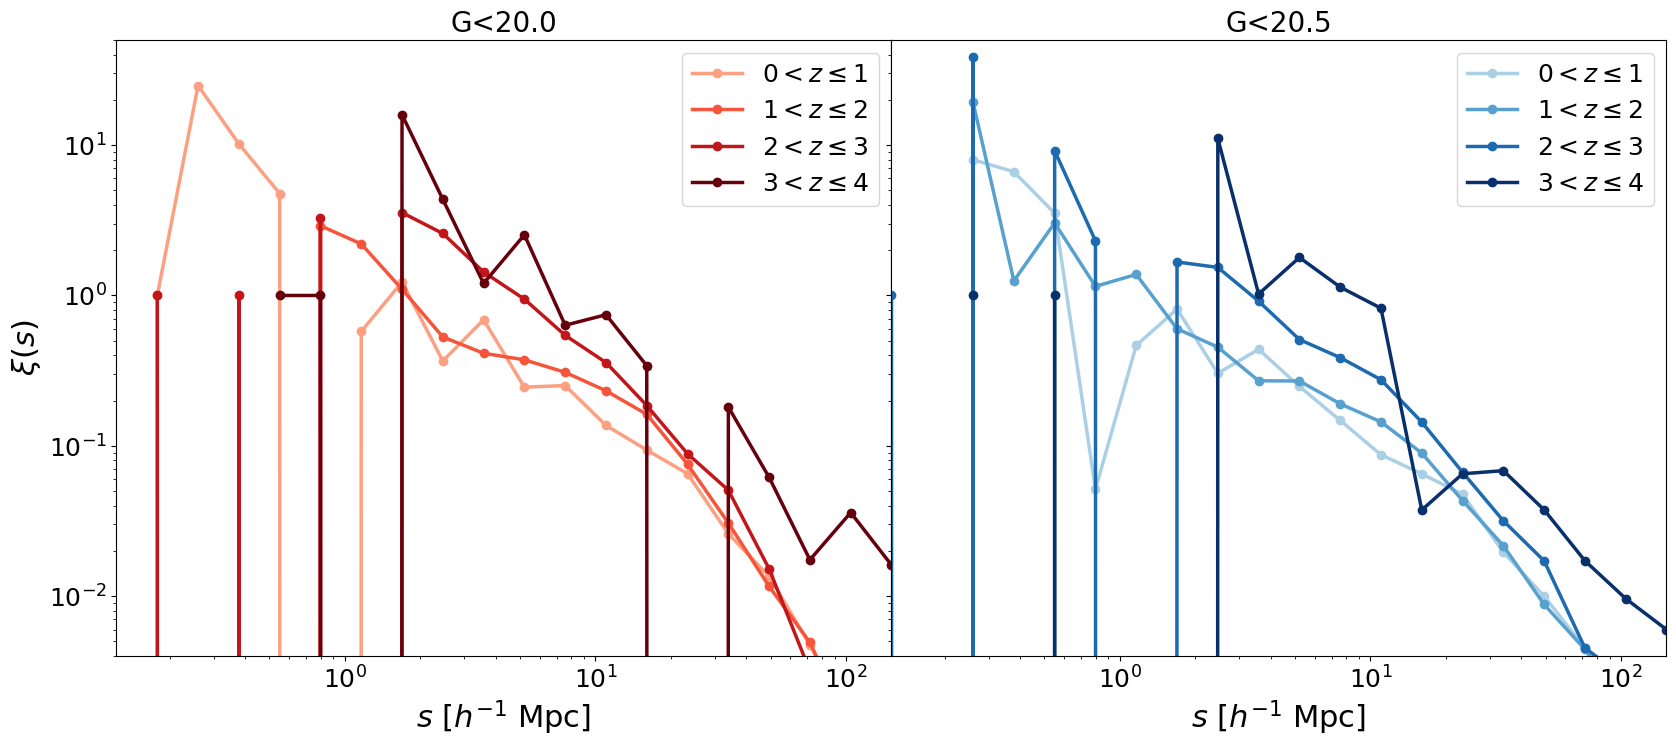

In [16]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array[:-1]:
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, color = cmaps[i][int(zbin)])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

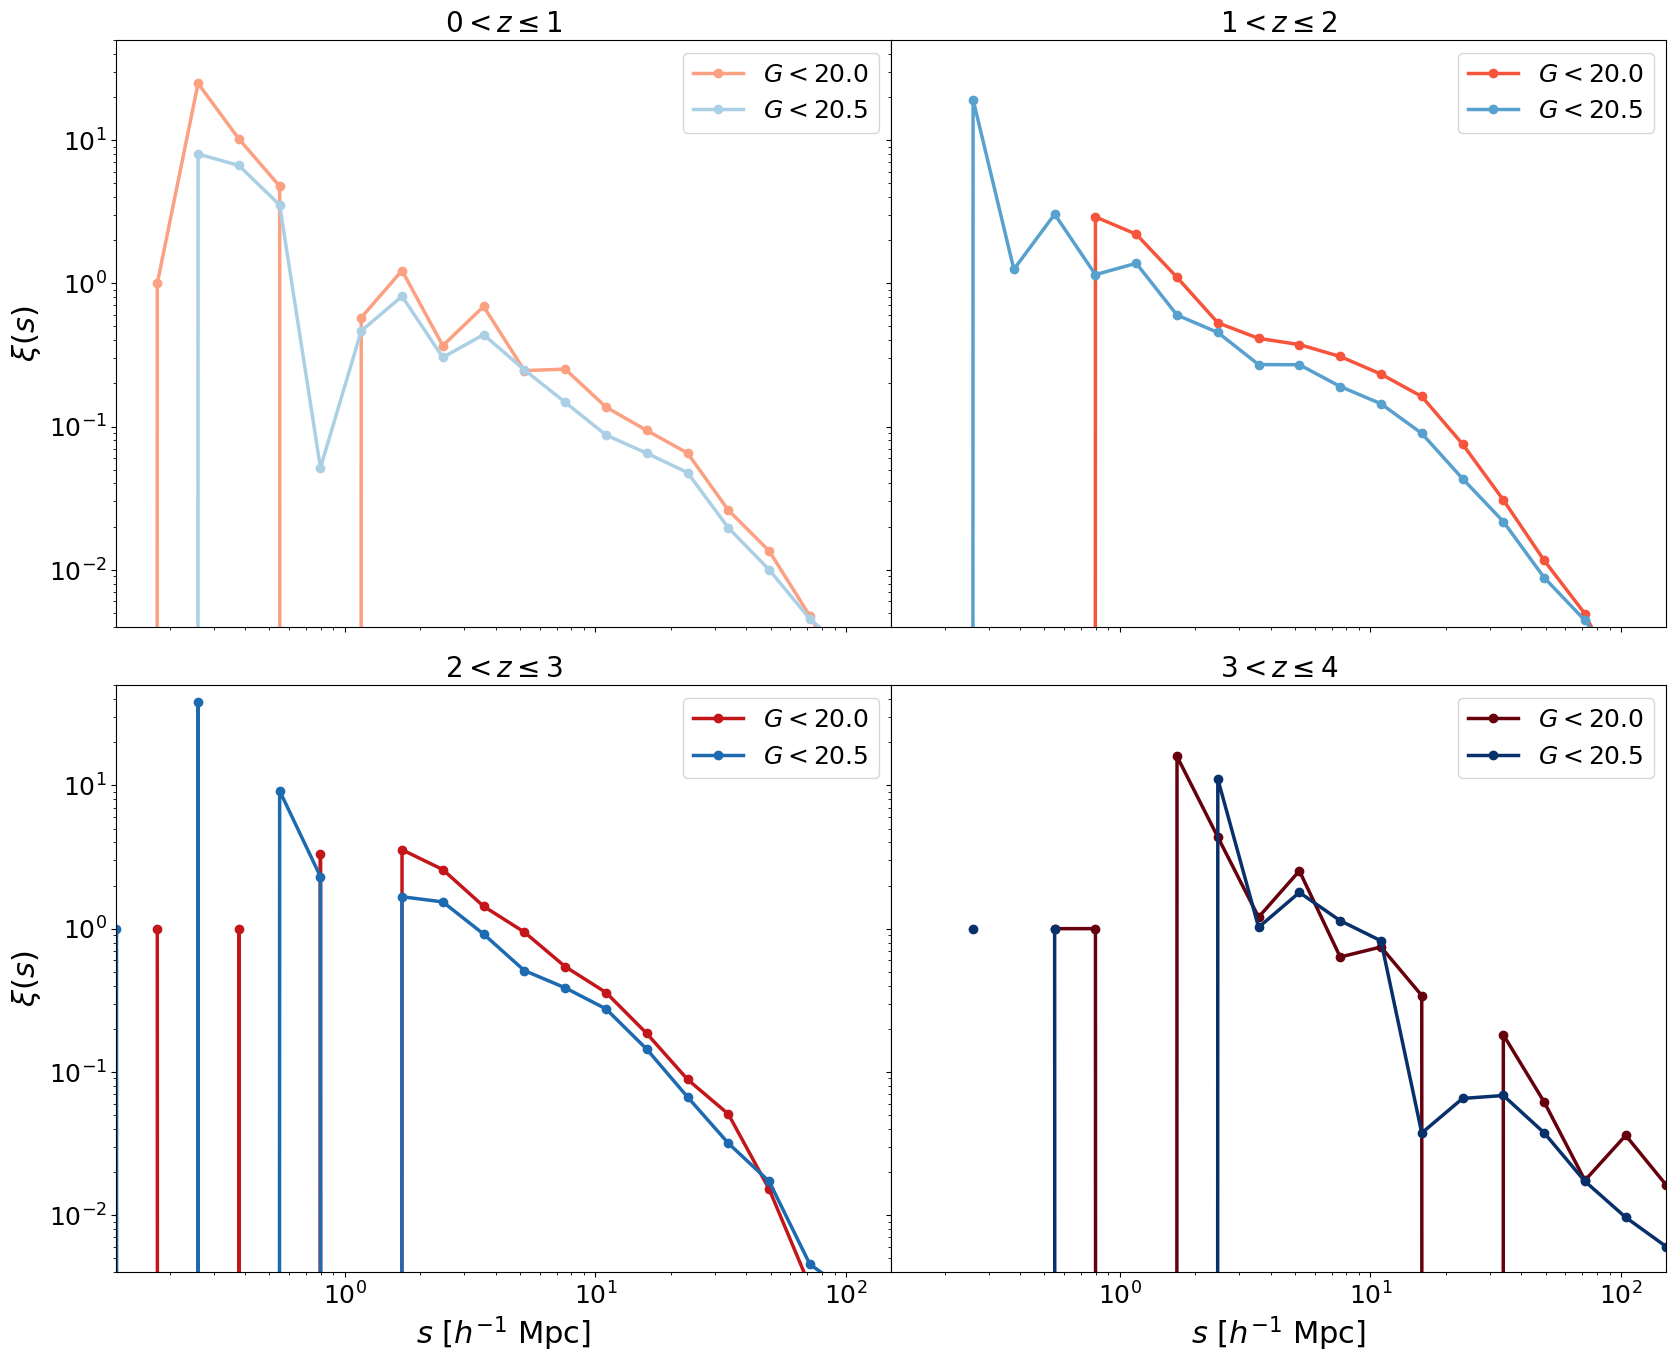

In [17]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    
    for i in range(len(G_array)):
        
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][int(zbin)], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][int(zbin)])
        
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(4e-3, 5e1)
    if zbin>1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])
    if zbin%2==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])
    ax1.legend()

plt.show()

## $w_p(r_p)$

In [18]:
# Create the bins array
rmin = 0.15
rmax = 240 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

In [19]:
pimax = 80 

In [20]:
# plot data
bins = np.linspace(0.08, 4.6)
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in G_array:

    for zbin in zbin_array[:-1]:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G, int(zbin), True, 'z', bins = zbin_array, 
                                                                                           tab_gcat_type = 'data', method = 'minmax')
        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                          rbins = rbins, nbins = nbins, pimax = pimax)
        
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

_G20.0_zmin0.0zmax1.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin1.0zmax2.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin2.0zmax3.0


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin2.0zmax3.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin3.0zmax4.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


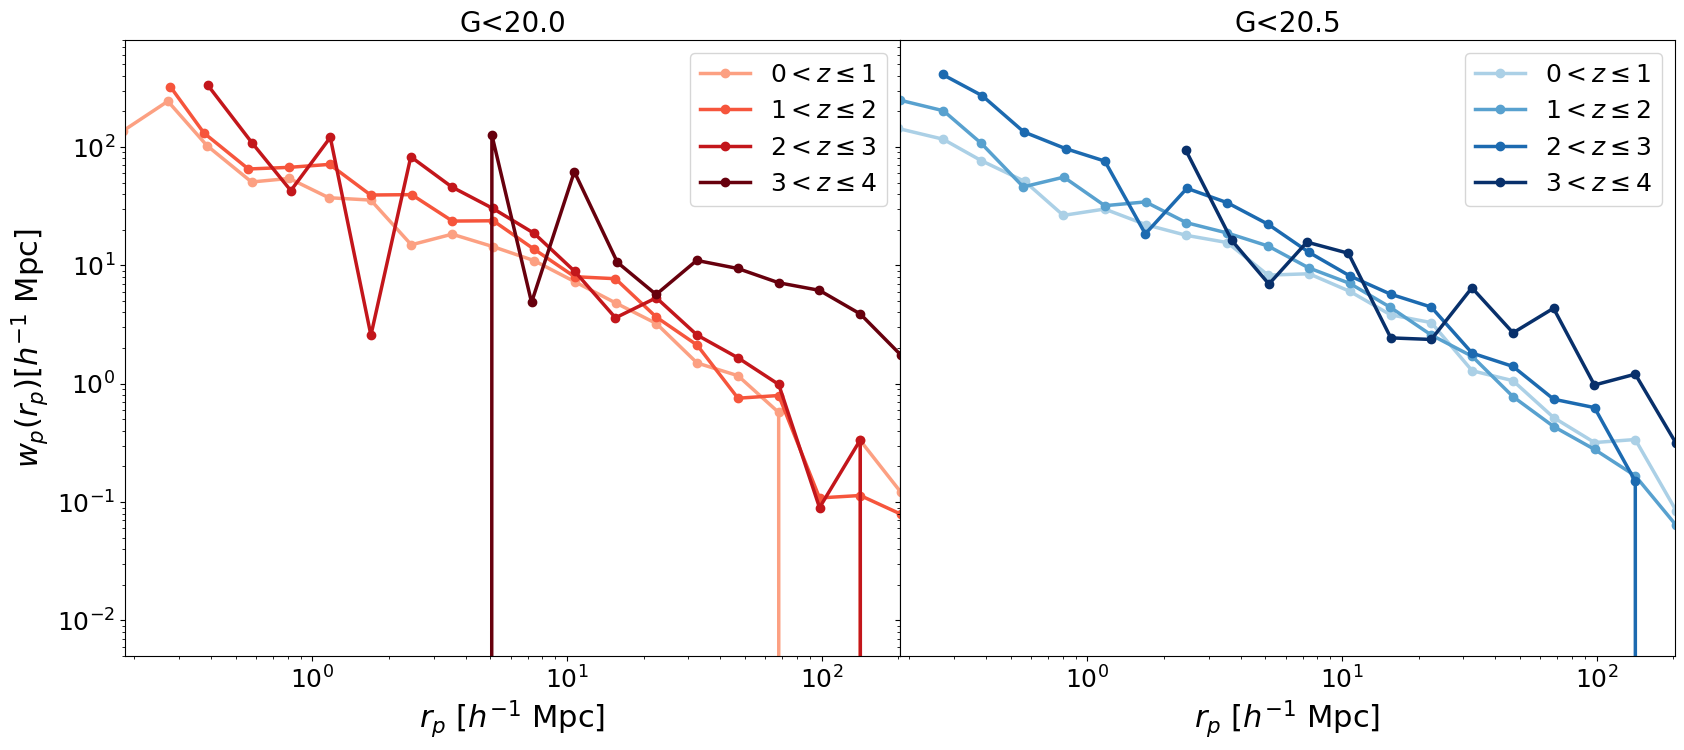

In [21]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for zbin in zbin_array[:-1]:
        
        ax1.plot(rpavg[G_array[i]][int(zbin)], wp[G_array[i]][int(zbin)], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, marker = 'o', color = cmaps[i][int(zbin)])
        
    ax1.set_title('G<{}'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(5e-3, 8e2)
    ax1.legend()
    
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

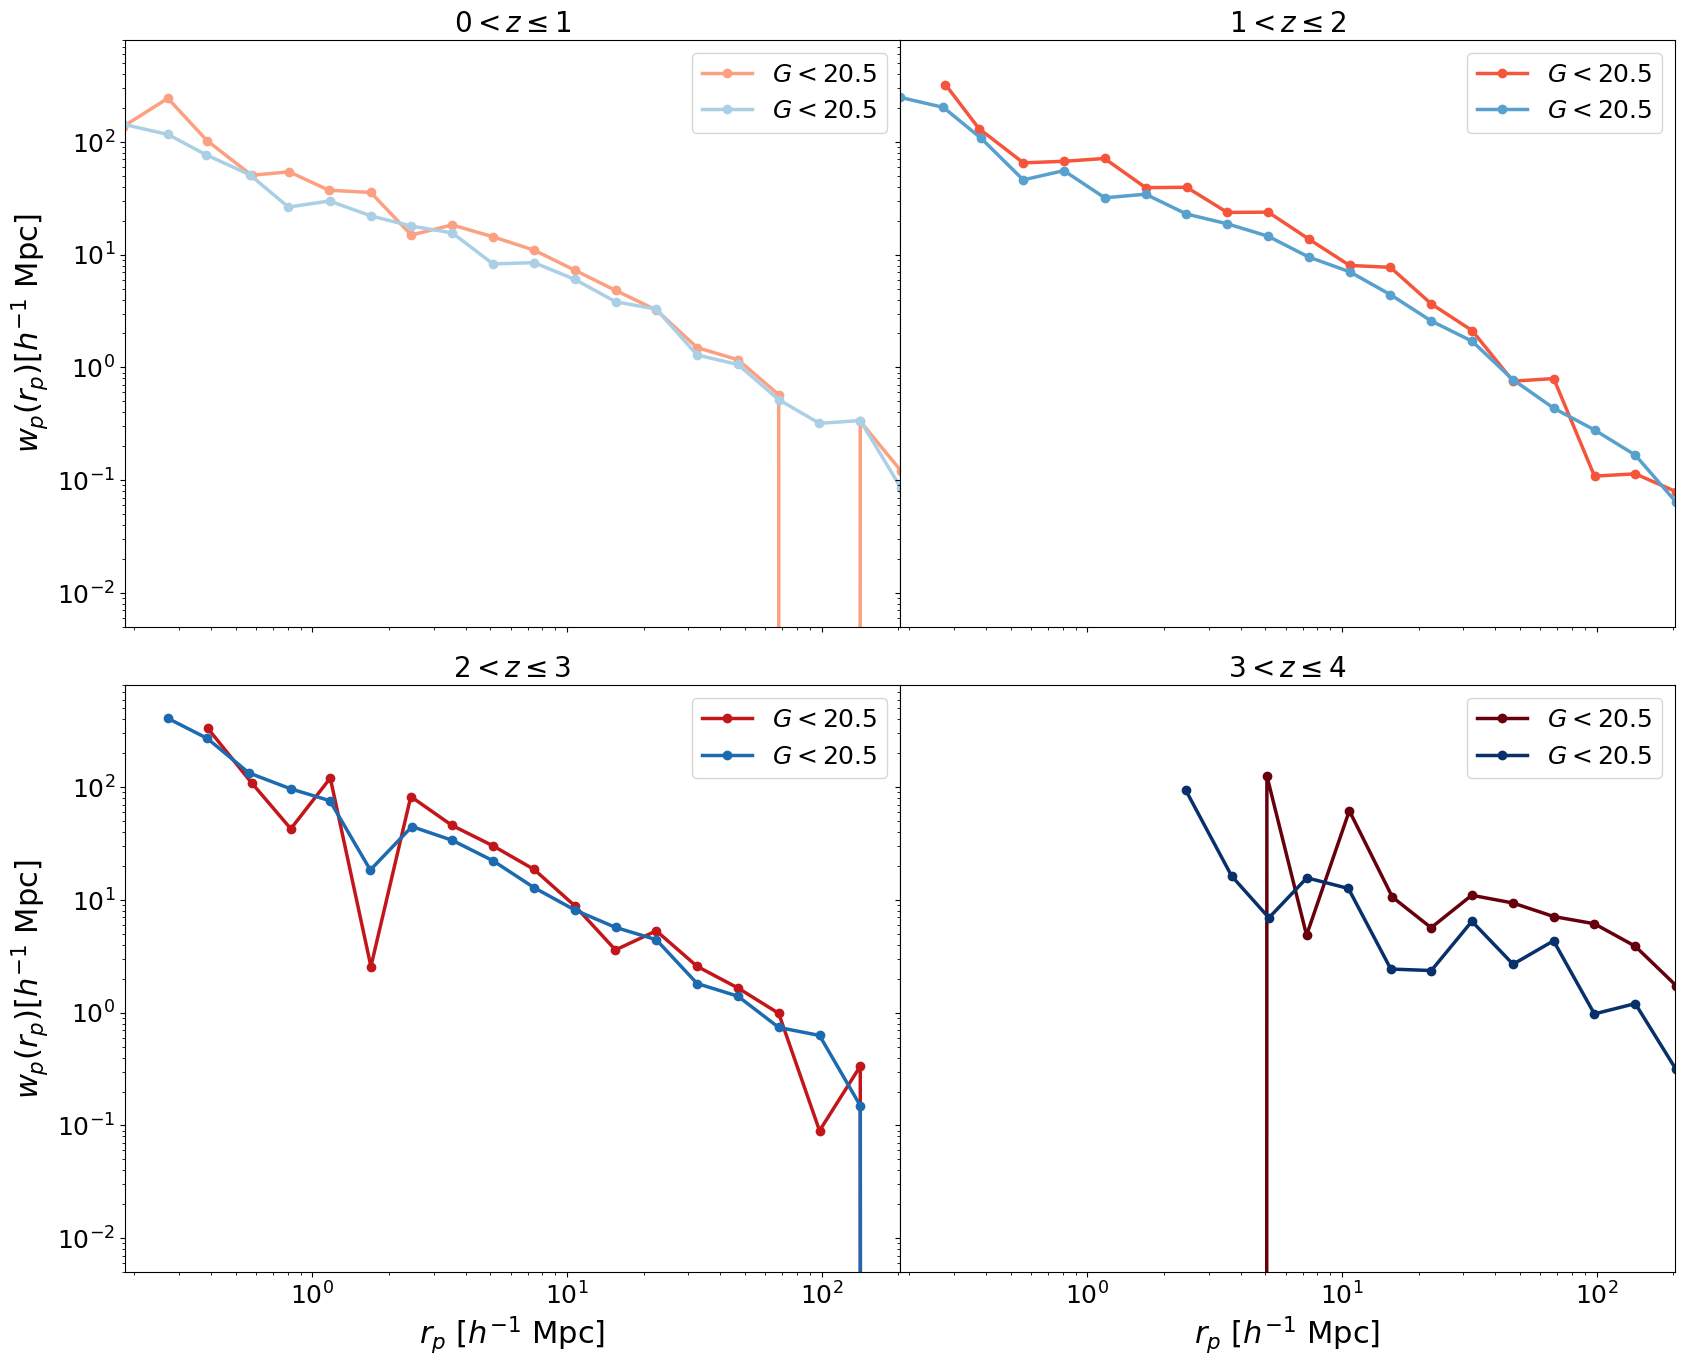

In [22]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    
    for i in range(len(G_array)):
        
        ax1.plot(rpavg[G_array[i]][int(zbin)], wp[G_array[i]][int(zbin)], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][int(zbin)])
        
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(5e-3, 8e2)
    ax1.legend()
    if zbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])
    if zbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

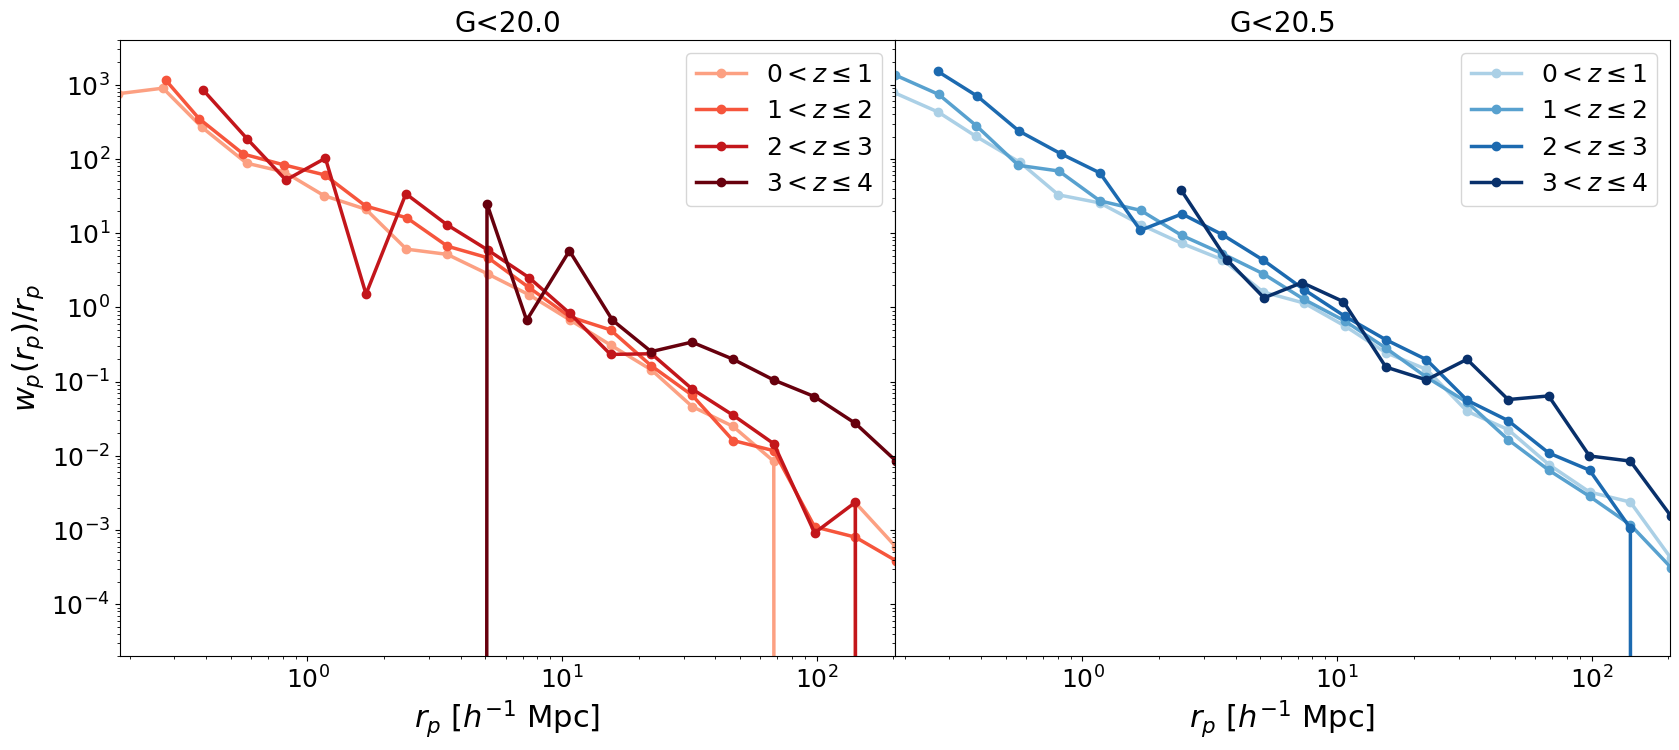

In [23]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for zbin in zbin_array[:-1]:
        
        ax1.plot(rpavg[G_array[i]][int(zbin)], wp[G_array[i]][int(zbin)]/rpavg[G_array[i]][int(zbin)], 
                 label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), linewidth = 2.5, marker = 'o', color = cmaps[i][int(zbin)])
        
    ax1.set_title('G<{}'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-5, 4e3)
    ax1.legend()
    
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

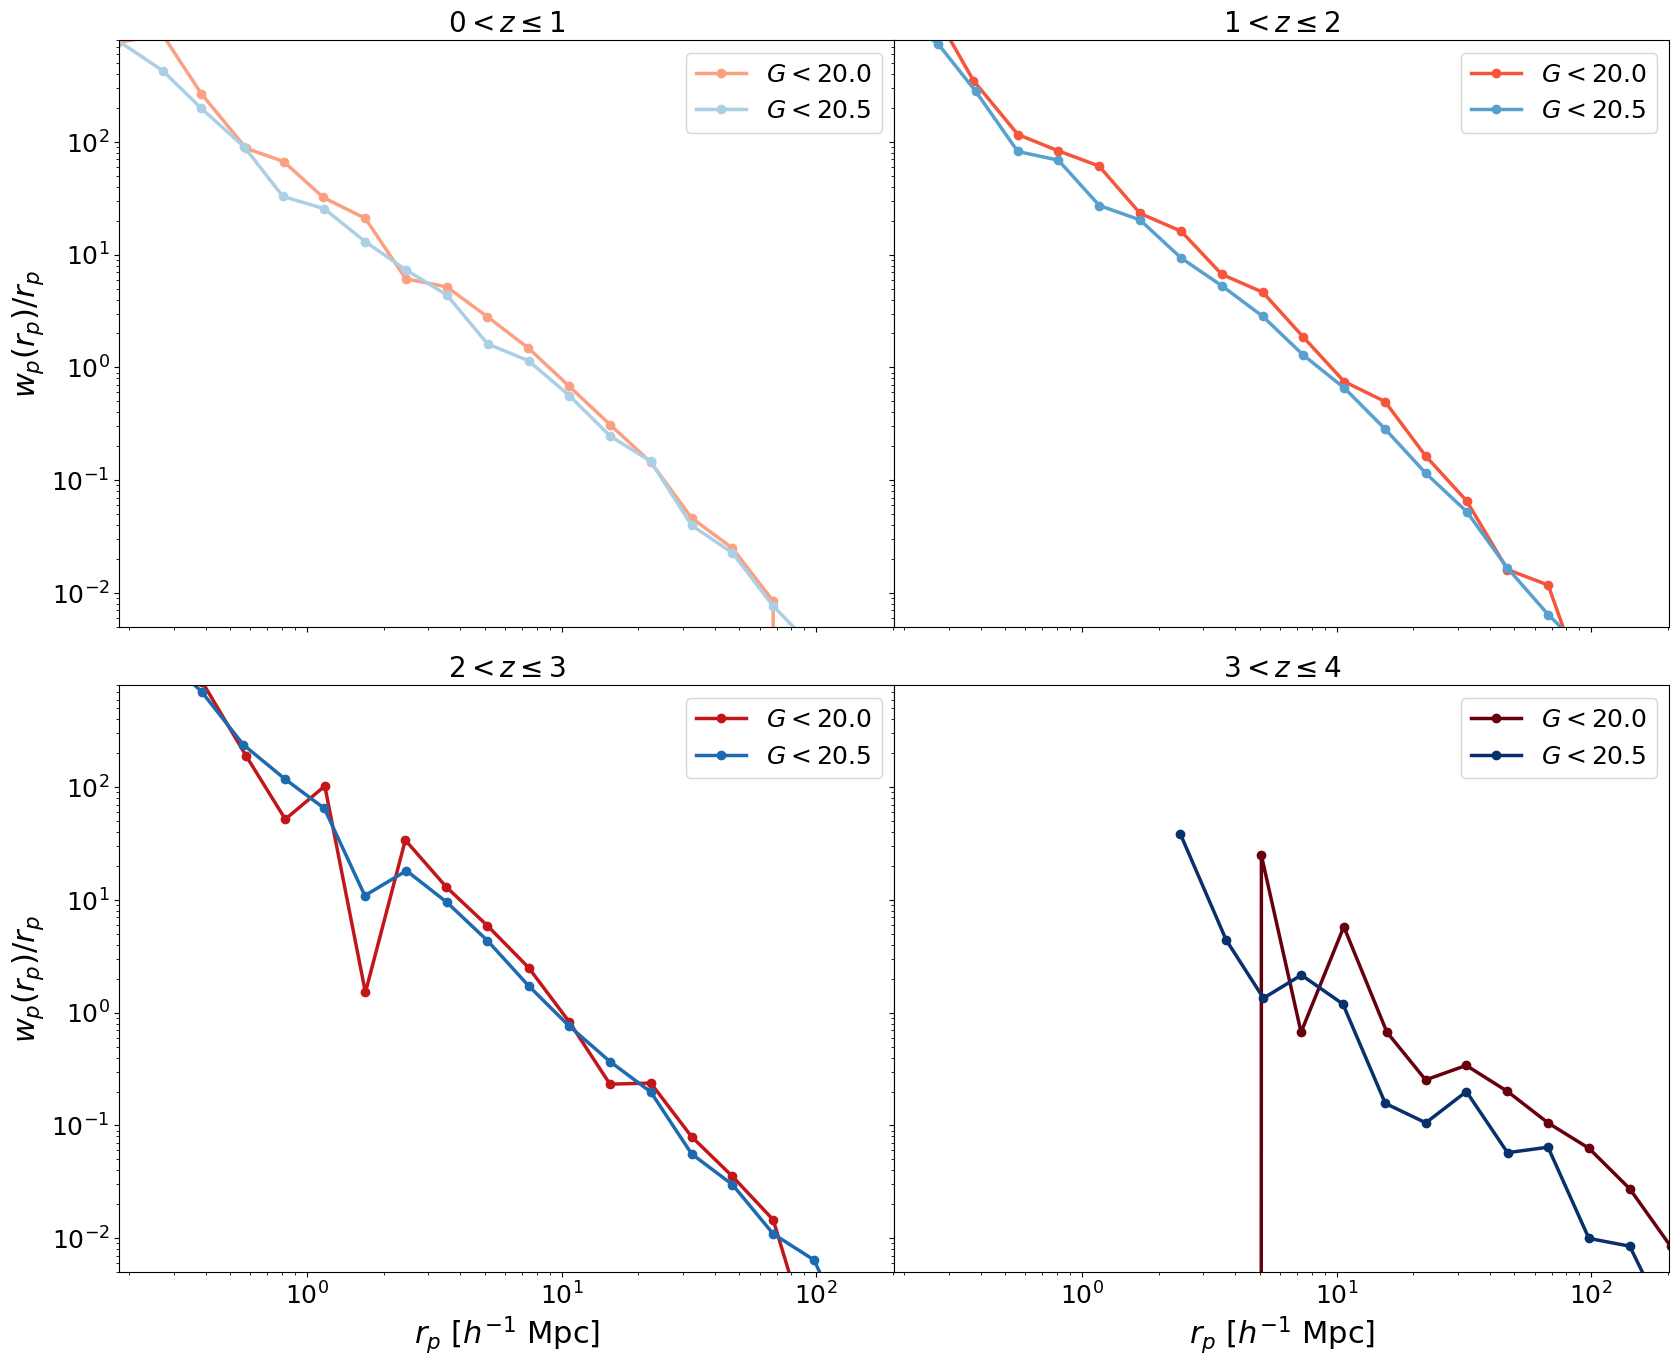

In [24]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    
    for i in range(len(G_array)):
        
        ax1.plot(rpavg[G_array[i]][int(zbin)], wp[G_array[i]][int(zbin)]/rpavg[G_array[i]][int(zbin)], label = '$G<{}$'.format(G_array[i]), 
                 linewidth = 2.5, marker = 'o', color = cmaps[i][int(zbin)])
        
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(5e-3, 8e2)
    ax1.legend()

    if zbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])
    if zbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

## $w(\theta)$

In [25]:
# Create the bins array
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) 

In [26]:
# plot data
wtheta = {20.0: [], 20.5: []}
for G in G_array:

    for zbin in zbin_array[:-1]:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, _, _, _ = quaia.make_bins(G, int(zbin), True, 'z', bins = zbin_array, 
                                                                                           tab_gcat_type = 'data', method = 'minmax')

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

_G20.0_zmin0.0zmax1.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 0.254486
DR: 6.329361
RR: 29.698912
_G20.0_zmin1.0zmax2.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 1.090173
DR: 26.609471
RR: 135.794817
_G20.0_zmin2.0zmax3.0


...

DD: 5.03473
DR: 116.287308
RR: 522.074385
_G20.5_zmin2.0zmax3.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 0.49448900000000007
DR: 12.206639
RR: 60.837242
_G20.5_zmin3.0zmax4.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 0.011002999999999999
DR: 0.151983
RR: 0.436175


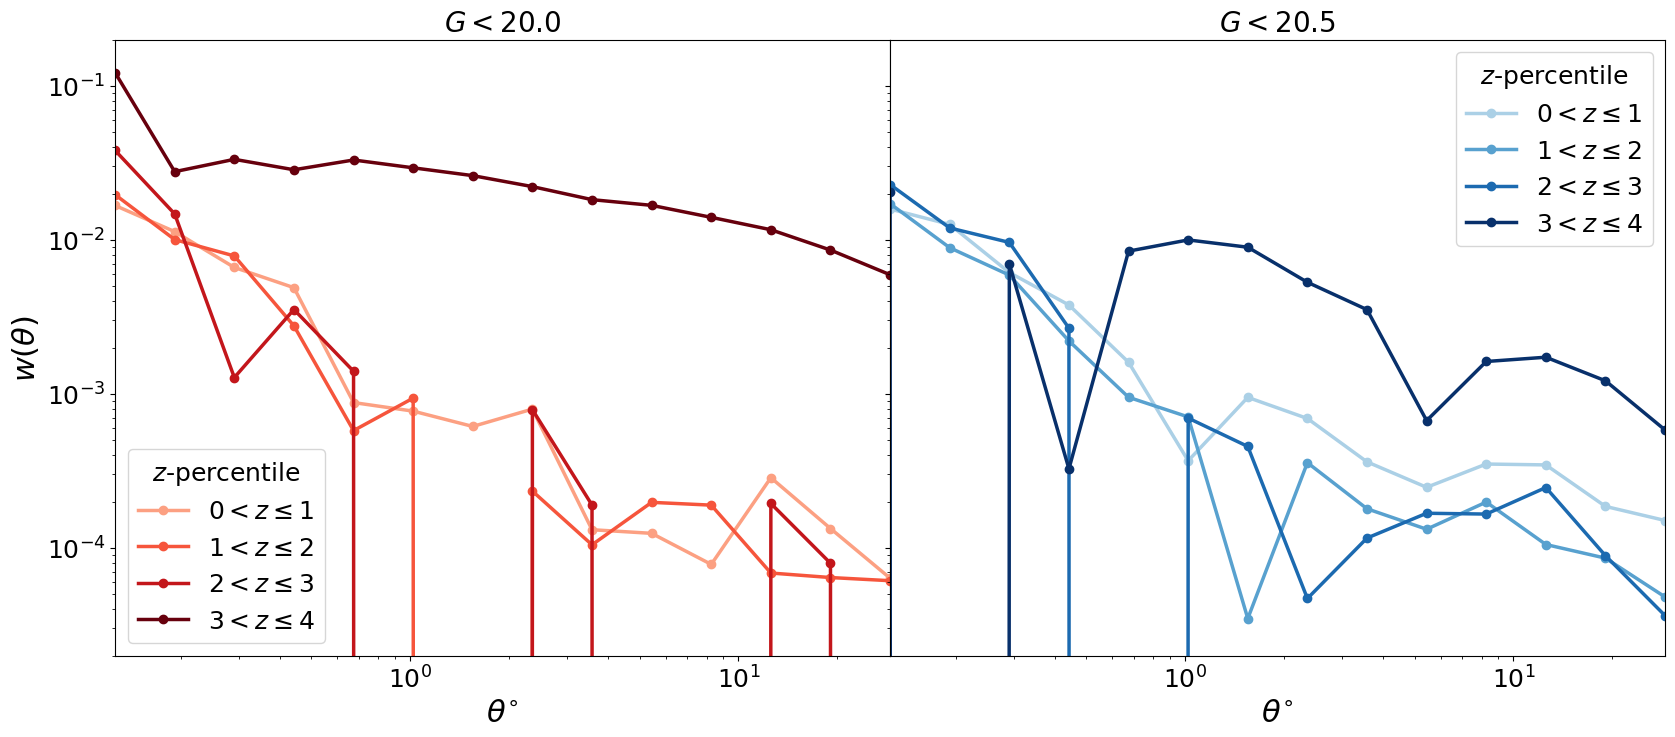

In [27]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for zbin in zbin_array[:-1]:
        
        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][int(zbin)], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, marker = 'o', color = cmaps[i][int(zbin)])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$\theta^{\circ}$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(2e-5, 2e-1)
    ax1.legend(title='$z$-percentile', title_fontsize = 18)
    
    if i==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()

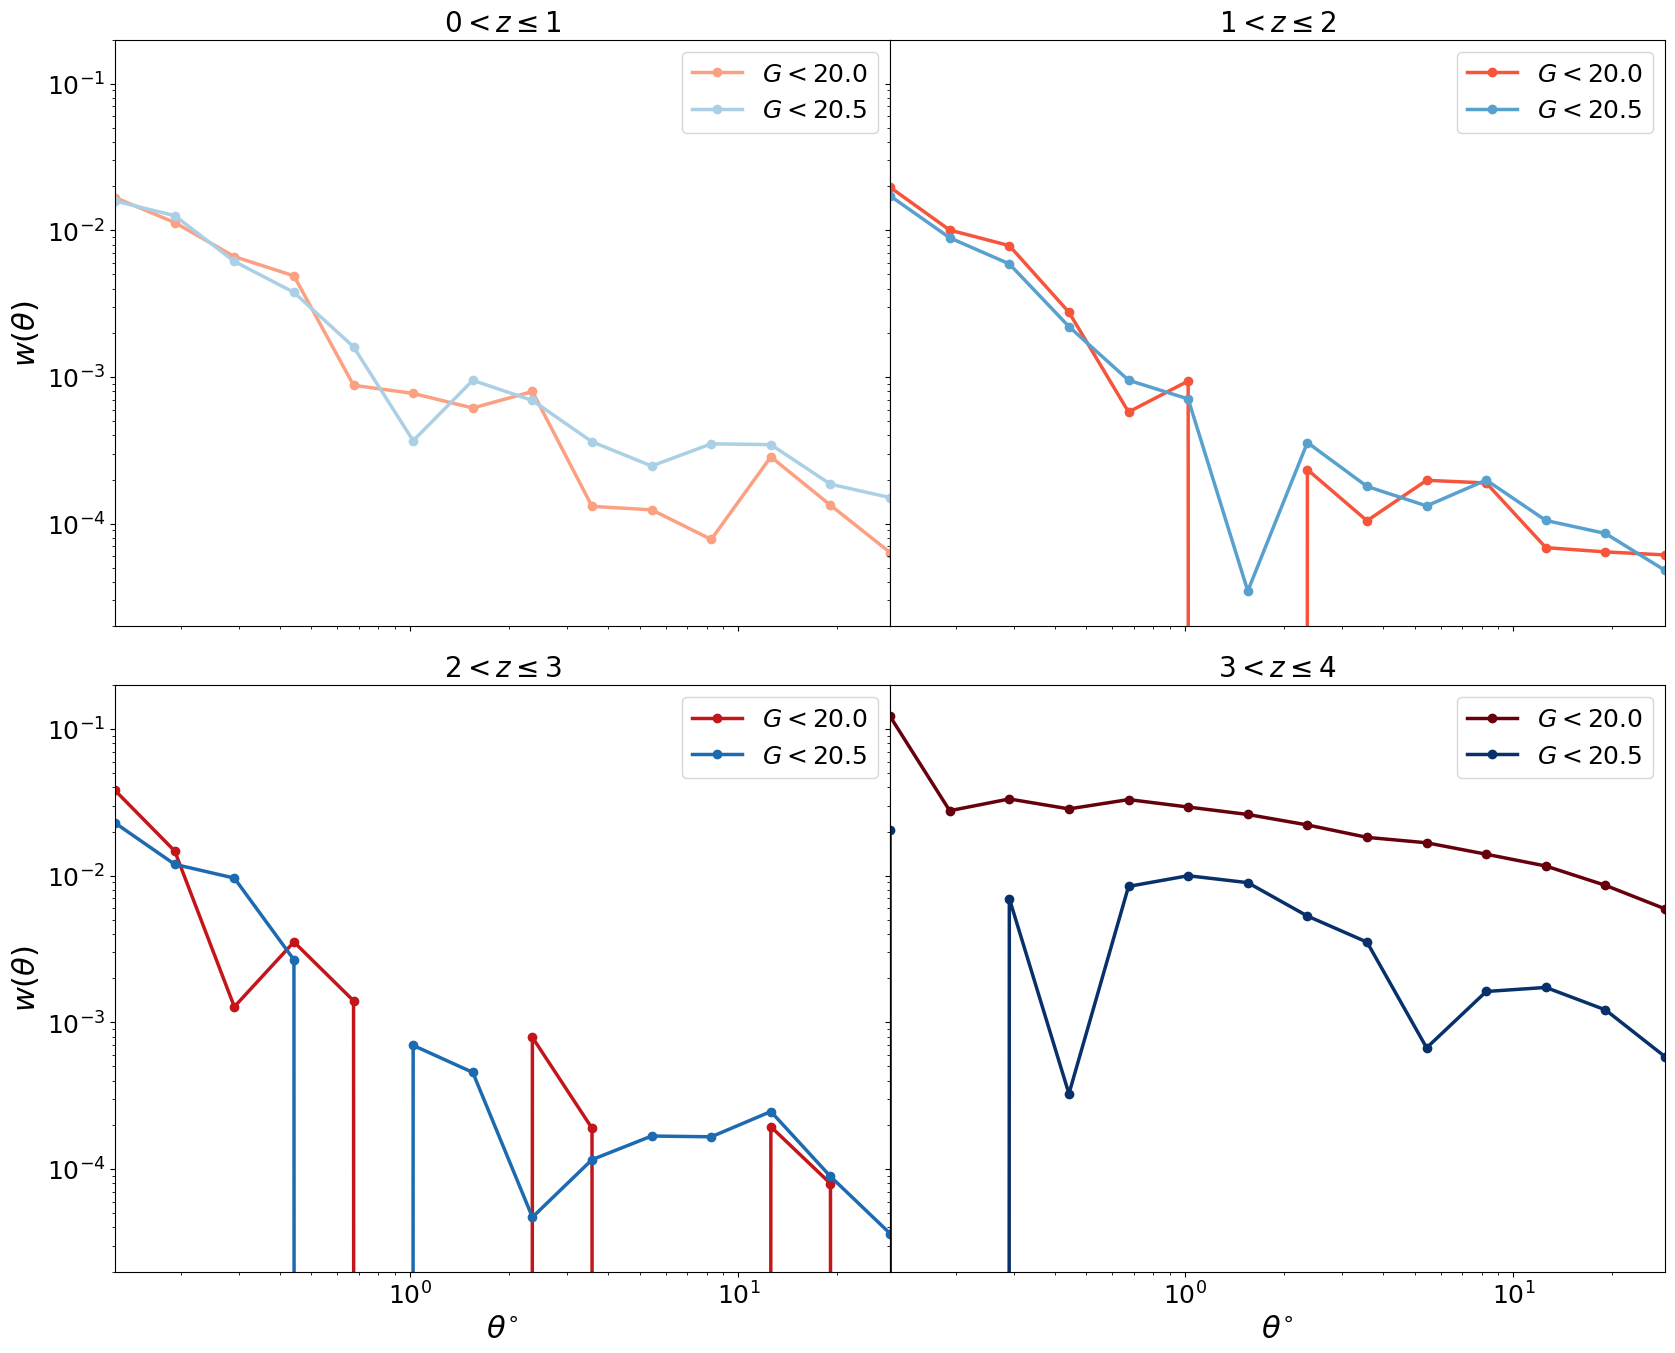

In [28]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    
    for i in range(len(G_array)):

        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][int(zbin)], label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][int(zbin)])
        
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(2e-5, 2e-1)
    ax1.legend()
    
    if zbin%2==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])
    if zbin<2:
        ax1.set_xticklabels([])
    else:
        ax1.set_xlabel(r'$\theta^{\circ}$')

plt.show()